# 01. EDA e Pré-processamento

## Contexto do problema

O objetivo aqui é prever a categoria de um produto a partir da sua descrição em texto. A variável que queremos prever, o target, é a coluna `categoria`, que tem mais de duas classes possíveis. Para fazer essa previsão contamos apenas com o texto da descrição do produto, na coluna `texto`.

## 1. Importando Bibliotecas

In [19]:
import sys
sys.path.append('./src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

from preprocessing import carregar_e_limpar, obter_ou_criar_split, medir_duplicatas_semanticas

import warnings
warnings.filterwarnings('ignore')

## 2. Carregamento

In [20]:
df_bruto = pd.read_csv('data/raw/dataset_ecommerce.csv')
print(f"Shape original: {df_bruto.shape}")
df_bruto.head()

Shape original: (50425, 2)


,categoria,texto
0,Household,Paper Plane Design Framed Wall Hanging Motivat...
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ..."
2,Household,SAF 'UV Textured Modern Art Print Framed' Pain...
3,Household,"SAF Flower Print Framed Painting (Synthetic, 1..."
4,Household,Incredible Gifts India Wooden Happy Birthday U...


## 3. Qualidade dos dados

In [21]:
df_bruto.info()

<class 'pandas.DataFrame'>
RangeIndex: 50425 entries, 0 to 50424
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   categoria  50425 non-null  str  
 1   texto      50424 non-null  str  
dtypes: str(2)
memory usage: 35.8 MB


In [22]:
print("Valores nulos por coluna:")
print(df_bruto.isna().sum())
print(f"\nLinhas totalmente duplicadas: {df_bruto.duplicated().sum()}")
print(f"Descrições de texto duplicadas: {df_bruto['texto'].duplicated().sum()}")
print(f"Textos vazios (string vazia após strip): {(df_bruto['texto'].astype(str).str.strip() == '').sum()}")
print(f"\nCategorias únicas antes da limpeza: {sorted(df_bruto['categoria'].dropna().unique())}")

Valores nulos por coluna:
categoria    0
texto        1
dtype: int64

Linhas totalmente duplicadas: 22622
Descrições de texto duplicadas: 22622
Textos vazios (string vazia após strip): 0

Categorias únicas antes da limpeza: ['Books', 'Clothing & Accessories', 'Electronics', 'Household']


## 4. Limpeza

A limpeza remove os registros com valores nulos, padroniza o nome da categoria `Clothing & Accessories` e tira espaços em branco extras. Ela também remove duplicatas exatas de texto e categoria, pelo motivo explicado logo abaixo.

In [23]:
df_sem_dedup = carregar_e_limpar('data/raw/dataset_ecommerce.csv', remover_duplicatas=False)
df = carregar_e_limpar('data/raw/dataset_ecommerce.csv')

n_nulos_removidos = df_bruto.shape[0] - df_sem_dedup.shape[0]
n_duplicatas_removidas = df_sem_dedup.shape[0] - df.shape[0]

print(f"Shape original: {df_bruto.shape}")
print(f"Após remover nulos: {df_sem_dedup.shape} (-{n_nulos_removidos} linha(s) com valores nulos)")
print(f"Shape após limpeza completa: {df.shape} (-{n_duplicatas_removidas} linha(s) duplicada(s) de texto+categoria)")
print(f"Categorias após padronização: {sorted(df['categoria'].unique())}")
df.head()

Shape original: (50425, 2)
Após remover nulos: (50424, 2) (-1 linha(s) com valores nulos)
Shape após limpeza completa: (27802, 2) (-22622 linha(s) duplicada(s) de texto+categoria)
Categorias após padronização: ['Books', 'Clothing_Accessories', 'Electronics', 'Household']


,texto,categoria
0,Paper Plane Design Framed Wall Hanging Motivat...,Household
1,"SAF 'Floral' Framed Painting (Wood, 30 inch x ...",Household
2,SAF 'UV Textured Modern Art Print Framed' Pain...,Household
3,"SAF Flower Print Framed Painting (Synthetic, 1...",Household
4,Incredible Gifts India Wooden Happy Birthday U...,Household


### Removendo duplicatas

Foram encontradas linhas com texto e categoria iguais, provavelmente relacionadas ao mesmo produto aparecendo mais de uma vez no catálogo. Isso pode ser um problema porque, na divisão entre treino e teste, o mesmo texto pode acabar nos dois conjuntos.

Nesse caso, o modelo estaria sendo testado com algo que já viu durante o treinamento, deixando as métricas artificialmente melhores. Por isso, verificamos quantos registros do teste possuem uma cópia idêntica no treino, considerando o mesmo texto e a mesma categoria.


In [24]:
from sklearn.model_selection import train_test_split

idx_sem_dedup = np.arange(len(df_sem_dedup))

y_sem_dedup = LabelEncoder().fit_transform(df_sem_dedup['categoria'])

idx_tr_sd, idx_te_sd = train_test_split(
    idx_sem_dedup,
    test_size=0.2,
    random_state=42,
    stratify=y_sem_dedup
)

chave = df_sem_dedup['texto'] + '||' + df_sem_dedup['categoria']

em_treino = set(chave.iloc[idx_tr_sd])

teste_com_gemeo_no_treino = chave.iloc[idx_te_sd].isin(em_treino).sum()

print(f"Linhas repetidas no teste: {teste_com_gemeo_no_treino}")
print(f"Total de linhas no teste: {len(idx_te_sd)}")
print(f"Porcentagem: {teste_com_gemeo_no_treino / len(idx_te_sd) * 100:.1f}%")


Linhas repetidas no teste: 6414
Total de linhas no teste: 10085
Porcentagem: 63.6%


In [25]:
chave_teste = chave.iloc[idx_te_sd]
chaves_repetidas = chave_teste[chave_teste.isin(em_treino)]
chave_exemplo = chaves_repetidas.iloc[0]
df_sem_dedup[
    chave == chave_exemplo
][['texto', 'categoria']]

,texto,categoria
25672,Sports Hour pool chalk (pack of 12 pcs) This B...,Books
25694,Sports Hour pool chalk (pack of 12 pcs) This B...,Books


## 5. Distribuição das categorias

,quantidade,percentual (%)
categoria,,
Household,10564,38.0
Books,6256,22.5
Clothing_Accessories,5674,20.4
Electronics,5308,19.1


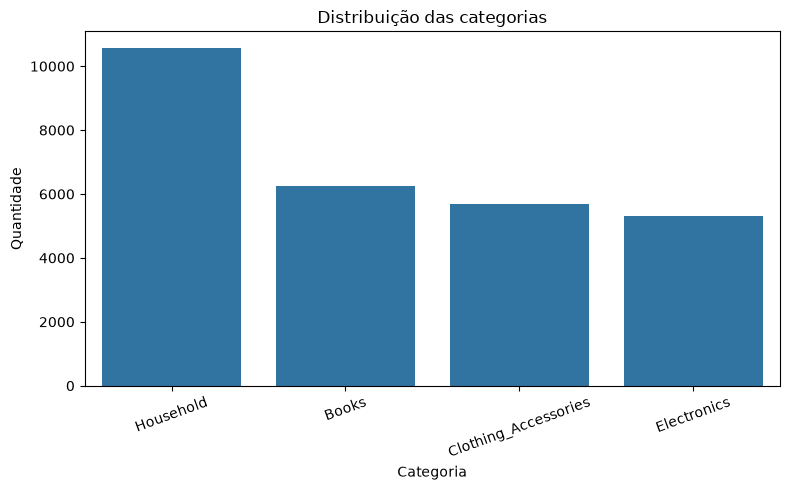

In [26]:
contagem = df['categoria'].value_counts()
percentual = (contagem / len(df) * 100).round(1)

resumo_categorias = pd.DataFrame({'quantidade': contagem, 'percentual (%)': percentual})
display(resumo_categorias)

plt.figure(figsize=(8, 5))
sns.barplot(x=contagem.index, y=contagem.values, order=contagem.index)
plt.title('Distribuição das categorias')
plt.ylabel('Quantidade')
plt.xlabel('Categoria')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('figs/01_distribuicao_categorias.png', dpi=100)
plt.show()

## 6. Análise do texto

,tamanho_texto,n_palavras
count,27802.000000,27802.000000
mean,699.997051,111.887094
std,1023.025018,166.116396
min,4.000000,1.000000
25%,215.000000,34.000000
50%,473.000000,76.000000
75%,916.750000,146.000000
max,50403.000000,8181.000000


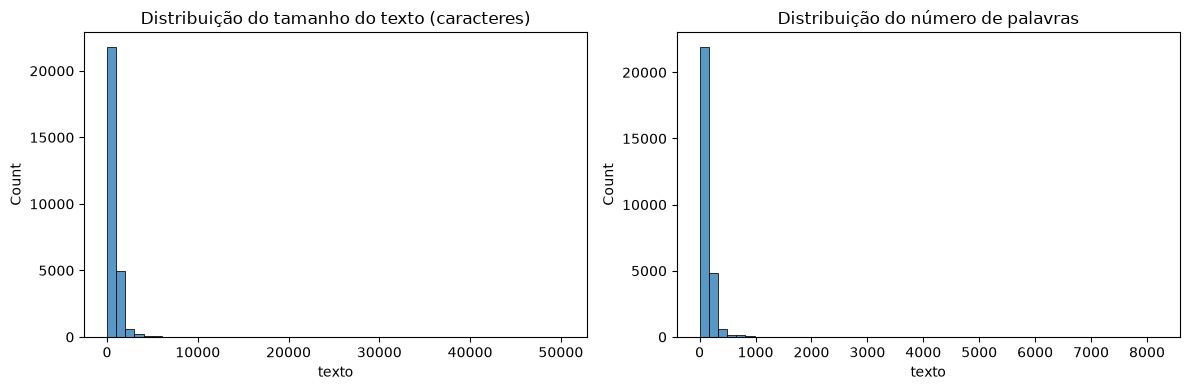

Texto mais curto: Yes!

Texto mais longo (300 primeiros caracteres): Risk Savvy: How to Make Good Decisions About the Author Gerd Gigerenzer is the author of Gut Feelings. He is currently the director of the Max Planck Institute for Human Development in Berlin, Germany, and lectures around the world on the importance of proper risk education for everyone from school-


In [27]:
tamanho_texto = df['texto'].str.len()
n_palavras = df['texto'].str.split().str.len()

display(pd.DataFrame({'tamanho_texto': tamanho_texto, 'n_palavras': n_palavras}).describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(tamanho_texto, bins=50, ax=axes[0])
axes[0].set_title('Distribuição do tamanho do texto (caracteres)')
sns.histplot(n_palavras, bins=50, ax=axes[1])
axes[1].set_title('Distribuição do número de palavras')
plt.tight_layout()
plt.savefig('figs/01_distribuicao_tamanho_texto.png', dpi=100)
plt.show()

print("Texto mais curto:", df.loc[tamanho_texto.idxmin(), 'texto'])
print("\nTexto mais longo (300 primeiros caracteres):", df.loc[tamanho_texto.idxmax(), 'texto'][:300])

### 6.1 Tamanho do texto por categoria

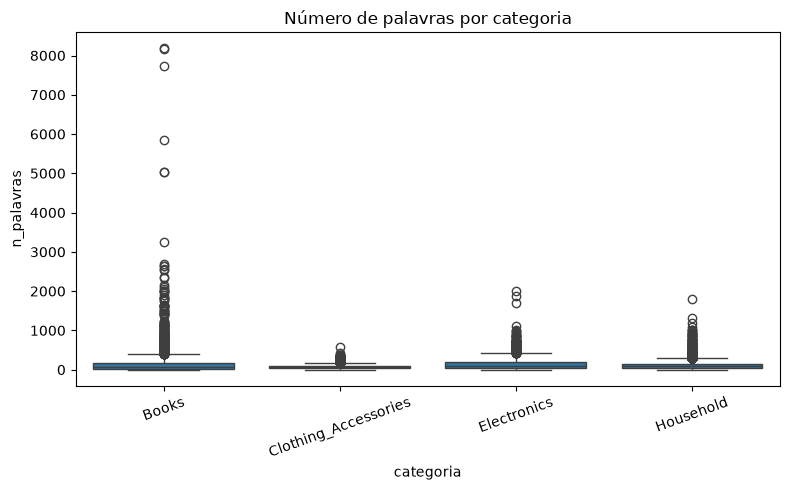

In [33]:
df_tmp = df.copy()
df_tmp['n_palavras'] = n_palavras

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_tmp, x='categoria', y='n_palavras', order=sorted(df['categoria'].unique()))
plt.title('Número de palavras por categoria')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('figs/01_palavras_por_categoria.png', dpi=100)
plt.show()


## 7. Exemplos de texto por categoria

In [29]:
print("Exemplo de texto por categoria:")
for cat in sorted(df['categoria'].unique()):
    exemplo = df[df['categoria'] == cat]['texto'].iloc[0]
    print(f"\n[{cat}] {exemplo[:200]}...")

Exemplo de texto por categoria:

[Books] Inner Engineering: A Yogi's Guide to Joy About the Author Sadhguru Jaggi VasudevSADHGURU is a yogi, mystic, and visionary who established the Isha Foundation, a nonprofit dedicated to the cultivation ...

[Clothing_Accessories] Woopower 36M Pink for 024M Baby Trouser Top Sets3Pcs Boy Girl Hooded Topsstriped Pantshairband Outfits36Mpink Size name36m colourpink description100 brand new and type children setgender unisexfor sea...

[Electronics] Dell 19.5V-3.34AMP 65W Laptop Adapter (Without power Cord) Design Features of Dell Laptop - Power adapter - 65 Watt (No Power Cable) The Dell 65-Watt Inspiron AC Power Adapter helps you to charge Dell...

[Household] Paper Plane Design Framed Wall Hanging Motivational Office Decor Art Prints (8.7 X 8.7 inch) - Set of 4 Painting made up in synthetic frame with uv textured print which gives multi effects and attract...


## 8. Encoding do target

O modelo não entende categorias em texto, então usamos o *LabelEncoder* para transformá-las em números (0, 1, 2, 3...). O *One-Hot Encoding* também é uma opção, mas é mais indicado quando a categoria é uma feature de entrada.

Como categoria é o alvo, o *LabelEncoder* é a opção mais simples e adequada neste caso.

In [30]:
le = LabelEncoder()
y = le.fit_transform(df['categoria'])

print("Mapeamento LabelEncoder:")
print(dict(zip(le.classes_, le.transform(le.classes_))))
print(f"\nPrimeiros 5 valores de y: {y[:5]}")

Mapeamento LabelEncoder:
{'Books': np.int64(0), 'Clothing_Accessories': np.int64(1), 'Electronics': np.int64(2), 'Household': np.int64(3)}

Primeiros 5 valores de y: [3 3 3 3 3]


## 9. Divisão treino/teste 

In [31]:
idx_train, idx_test = obter_ou_criar_split(df, y, caminho_split='data/processed/split.npz', test_size=0.2, random_state=42)
y_train, y_test = y[idx_train], y[idx_test]

print(f"Treino: {len(idx_train)} registros | Teste: {len(idx_test)} registros")
print("Distribuição treino (%):", np.round(np.bincount(y_train) / len(y_train) * 100, 1))
print("Distribuição teste (%): ", np.round(np.bincount(y_test) / len(y_test) * 100, 1))

Treino: 22241 registros | Teste: 5561 registros
Distribuição treino (%): [22.5 20.4 19.1 38. ]
Distribuição teste (%):  [22.5 20.4 19.1 38. ]
